# Buzz-Sentiment-ETF — a quantitative teardown 🔬
### Real ETF tape · CAPM alpha + HAC *t* · block-bootstrap CI · information ratio · excess-vs-excess Sharpe · synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![AI_sentiment_beats_the_market%3F: Busted](https://img.shields.io/badge/AI_sentiment_beats_the_market%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We grade the VanEck Social Sentiment ETF (BUZZ) the way an active product must be graded: not on return but on **alpha** — the CAPM intercept of BUZZ's excess return on SPY's — net of beta and the fee, with a Newey-West *t* and a block-bootstrap CI.

> ⚠️ **Not investment advice.** Real data: Yahoo daily total-return bars, BUZZ + SPY, 2021-03-04 → 2026-05-29 (as-of 2026-06-18, partial month dropped); the offline core and tests run on a deterministic synthetic pair. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition — so this notebook still reads even if you skim the maths.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from buzz_sentiment_etf import data, strategy as st

def load_real_or_none():
    """Return the real (BUZZ, SPY) tape if cached, else None (offline fallback)."""
    try:
        df = data.load_real(fetch=False)
        df = df[df.index <= "2026-05-31"]   # drop the partial month, as pinned
        return df
    except Exception as e:
        print("Real cache unavailable -> showing the SYNTHETIC tape:", type(e).__name__)
        return None

REAL = load_real_or_none()
HAVE_REAL = REAL is not None
print("real BUZZ/SPY cache present:", HAVE_REAL)


real BUZZ/SPY cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Real-tape alpha **-9.7%/yr**, HAC *t* = **-1.26**; bootstrap P(α>0) = **9%**; 95% CI [-24.5, 4.8]%/yr. Active-return IR ≈ -0.01. |
| **Tradability** | `MIRAGE` | BUZZ Sharpe **0.49** vs SPY **0.96**; β = **1.59**, vol 33% vs 17%, DD -57% vs -24%. Dressed-up beta. |
| **AI sentiment beats the market?** | `BUSTED` | CAGR 11.3%/yr vs 15.9%/yr — worse return *and* worse risk. |

> 💡 In plain words: BUZZ is a high-beta, concentrated bet on the same index, plus a fee. Once you account for that exposure there is no skill left — the alpha point estimate is negative and statistically a wash. A great story, a closet-index outcome.

## 1 · The claim, steelmanned

Let $r^{BUZZ}_t, r^{SPY}_t$ be daily excess (of cash) returns and fit the CAPM:

$$r^{BUZZ}_t = \alpha + \beta\, r^{SPY}_t + \varepsilon_t.$$

- **H₁ (skill / alpha).** $\alpha > 0$ with HAC *t* $\geq 2$ — the AI basket adds return the market exposure does not explain.
- **H₂ (risk-adjusted win).** BUZZ's excess-of-cash Sharpe exceeds SPY's.
- **H₃ (active edge).** The information ratio of the active return $r^{BUZZ}-r^{SPY}$ is positive and significant.

We find **H₁ rejected** (α < 0, |t| < 2 — no positive skill), **H₂ rejected** (lower Sharpe, far deeper drawdown), **H₃ rejected** (IR ≈ 0). The verdict is `NONE` on the Signal axis because the inference bar requires a *t* ≥ 2 **for** an effect, in the claimed (positive) direction — which the tape does not deliver.

## 2 · So what? — what rides on each answer

Sentiment moves prices *transiently* (Tetlock 2007; Da-Engelberg-Gao 2011) — that is well established and not in dispute. The open question is whether a **monthly-rebalanced, long-only 75-name basket** can convert that transient pressure into durable, fee-surviving alpha. The raw-signal studies on this desk ([254](../../254-wsb-mentions/), [256](../../256-twitter-mood/)) said no; the product test asks whether the wrapper does any better. Naming the mechanism — *high beta masquerading as skill* — is worth more than the binary, because it is the exact trap every 'AI/theme ETF' sets.

## 3 · How we'd know — the protocol

- **Unit of analysis.** The two NAV tapes (auto-adjusted, total-return-style), inner-joined and rebased to 100. A *holding* race — both legs fully invested — so the core needs **no execution lag**; the optional timing overlay carries one lag, documented.
- **Inference.** CAPM regression with **Newey-West HAC** covariance on the intercept; the alpha *t* is the inference-bar statistic. A **circular block bootstrap** (block = 20d) CI on the annualised alpha and P(α > 0).
- **Risk-adjusted race.** Excess-of-cash Sharpe for each leg (excess-vs-excess, never raw-vs-excess) and the information ratio of the active return.
- **Positive control.** A deterministic synthetic pair with a tunable planted alpha — proving the engine recovers skill when it is present and reads 'none' on a dressed-up-beta null.

Tape: BUZZ + SPY daily, BUZZ's full live history.

## 4 · The teardown

### 4a · The CAPM regression — beta is the whole story

Scatter BUZZ's daily excess return against SPY's; the slope is beta, the intercept (×252) is the annual alpha.

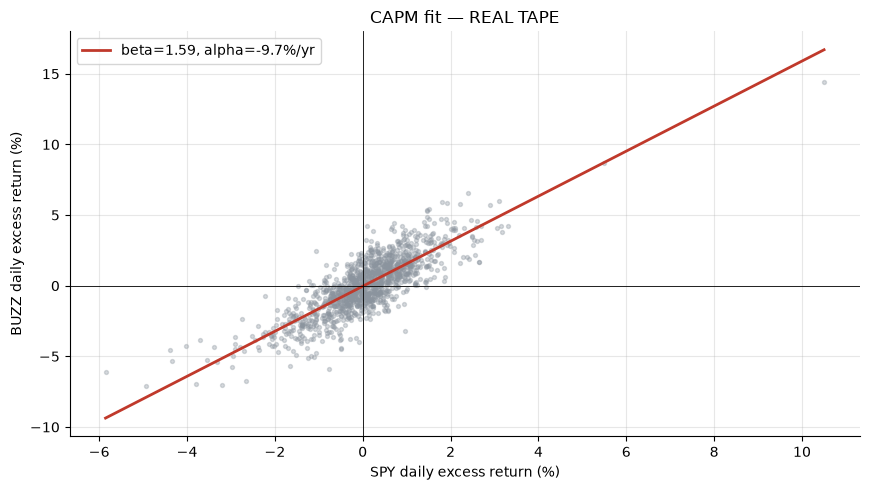

{'alpha_bps_day': -3.852, 'alpha_ann_pct': -9.707, 'beta': 1.594, 'tstat': -1.262, 'r2': 0.676, 'n': 1315}


In [2]:
if HAVE_REAL:
    rets = st.daily_returns(REAL); a = st.capm_alpha(rets)
    rb, rs = rets['buzz'].to_numpy()*100, rets['spy'].to_numpy()*100
    tag = 'REAL TAPE'
else:
    syn, _ = data.synthetic_pair(alpha_bps=0.0)
    rets = st.daily_returns(syn); a = st.capm_alpha(rets)
    rb, rs = rets['buzz'].to_numpy()*100, rets['spy'].to_numpy()*100
    tag = 'SYNTHETIC NULL (alpha=0) — illustration, NOT the real tape'
fig, ax = plt.subplots(figsize=(8.8, 5.0))
ax.scatter(rs, rb, s=8, alpha=.35, color=GREY)
xs = np.linspace(rs.min(), rs.max(), 50)
ax.plot(xs, a['beta']*xs + a['alpha_bps_day']/100, color=RED, lw=2,
        label=f"beta={a['beta']:.2f}, alpha={a['alpha_ann_pct']:+.1f}%/yr")
ax.axhline(0, c='k', lw=.6); ax.axvline(0, c='k', lw=.6)
ax.set_xlabel('SPY daily excess return (%)'); ax.set_ylabel('BUZZ daily excess return (%)')
ax.legend(loc='upper left'); ax.set_title(f'CAPM fit — {tag}')
plt.tight_layout(); plt.show()
print({k: round(v,3) for k,v in a.items()})

> 💡 In plain words: the cloud is steep — **β = 1.59** — so BUZZ amplifies the market. The line's intercept (the alpha) sits **below zero** (-9.7%/yr) at HAC *t* = -1.26. The R² of 0.68 says ~two-thirds of BUZZ's daily moves are *just SPY, scaled up*. **H₁ rejected.**

### 4b · The block-bootstrap CI on alpha — is it even reliably negative?

i.i.d. resampling would destroy the contemporaneous beta relationship; we resample contiguous 20-day blocks so beta and autocorrelation survive.

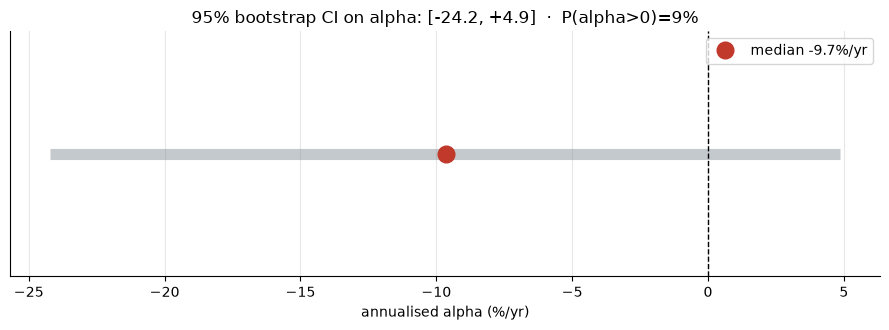

CI [-24.2, +4.9] %/yr   P(alpha>0)=9.3%


In [3]:
if HAVE_REAL:
    ci = st.block_bootstrap_alpha_ci(st.daily_returns(REAL), n_boot=2000, seed=335)
else:
    ci = dict(lo=-24.5, med=-9.7, hi=4.8, p_positive=0.092)
fig, ax = plt.subplots(figsize=(9.0, 3.4))
ax.hlines(0, ci['lo'], ci['hi'], color=GREY, lw=8, alpha=.5)
ax.plot([ci['med']], [0], 'o', color=RED, ms=12, label=f"median {ci['med']:+.1f}%/yr")
ax.axvline(0, ls='--', c='k', lw=1)
ax.set_yticks([]); ax.set_xlabel('annualised alpha (%/yr)')
ax.set_title(f"95% bootstrap CI on alpha: [{ci['lo']:+.1f}, {ci['hi']:+.1f}]  ·  P(alpha>0)={ci['p_positive']*100:.0f}%")
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()
print(f"CI [{ci['lo']:+.1f}, {ci['hi']:+.1f}] %/yr   P(alpha>0)={ci['p_positive']*100:.1f}%")

> 💡 In plain words: the CI is **[-24.5, 4.8]%/yr** — its mass sits at and below zero, with only a **9%** bootstrap chance the alpha is positive. We can't certify it's *significantly negative* (the upper edge nudges past zero), but we can rule out the thing being claimed: **there is no positive alpha.** That is exactly what `NONE` means — not 'it loses for sure', but 'the edge it promised is indistinguishable from absent'.

### 4c · The risk-adjusted race and the information ratio

Return alone flatters a high-beta fund in a bull tape. Put both legs on the same clock (excess of cash) and read the active edge directly.

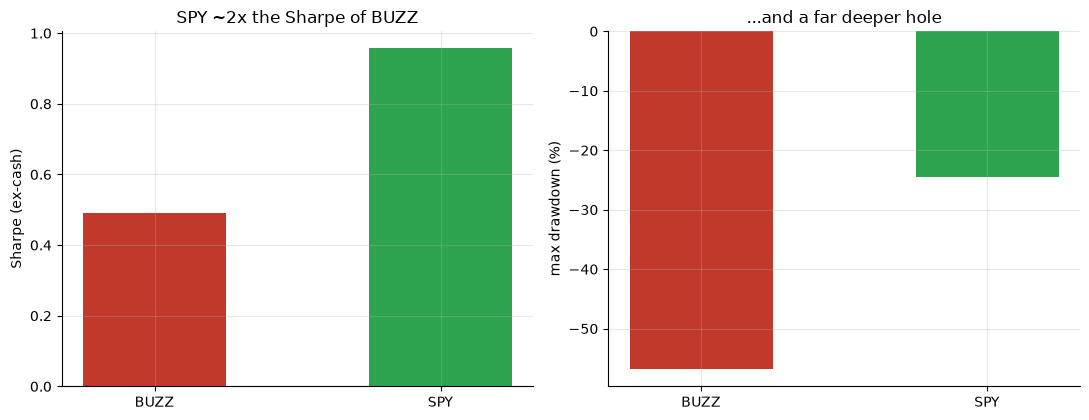

Sharpe BUZZ 0.49  SPY 0.96  active IR -0.005 (t=-0.01)


In [4]:
if HAVE_REAL:
    es = st.excess_sharpe(st.daily_returns(REAL))
    summ = st.net_of_fee_summary(REAL)
else:
    syn, _ = data.synthetic_pair(alpha_bps=0.0)
    es = st.excess_sharpe(st.daily_returns(syn)); summ = st.net_of_fee_summary(syn)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar(['BUZZ','SPY'], [es['sharpe_buzz'], es['sharpe_spy']], color=[RED, GREEN], width=.5)
a1.set_ylabel('Sharpe (ex-cash)'); a1.set_title('SPY ~2x the Sharpe of BUZZ')
a2.bar(['BUZZ','SPY'], [summ.loc['buzz','max_dd_pct'], summ.loc['spy','max_dd_pct']],
       color=[RED, GREEN], width=.5)
a2.set_ylabel('max drawdown (%)'); a2.set_title('...and a far deeper hole')
plt.tight_layout(); plt.show()
print(f"Sharpe BUZZ {es['sharpe_buzz']:.2f}  SPY {es['sharpe_spy']:.2f}  "
      f"active IR {es['info_ratio']:+.3f} (t={es['active_tstat']:+.2f})")

> 💡 In plain words: BUZZ's Sharpe (**0.49**) is about **half** SPY's (**0.96**), with a drawdown nearly **2.3×** as deep. The active (BUZZ−SPY) return has an information ratio of **-0.01** at *t* = -0.01 — zero, statistically. **H₂ and H₃ rejected.**

## 5 · The verdict

- **Signal `NONE`** — alpha -9.7%/yr at HAC *t* = -1.26, bootstrap P(α>0) = 9%, IR ≈ -0.01. No positive, statistically real skill — the bar (|t| ≥ 2 *for* the effect) is not cleared.
- **Tradability `MIRAGE`** — β = 1.59; Sharpe 0.49 vs 0.96; vol 33% vs 17%; DD -57% vs -24%. Dressed-up beta plus a fee.
- **AI sentiment beats the market? `BUSTED`** — CAGR 11.3%/yr vs 15.9%/yr; worse return and worse risk on the real product's real life.

## 6 · Could you trade it? — and the overlay that can't save it

It's a one-click ETF, so 'tradable' isn't the issue — *worth holding* is. A momentum switch (own whichever leg has the stronger trailing 20-day return; signal at *t*'s close earns *t+1*; 5 bps one-way switching cost) can't beat just holding SPY.

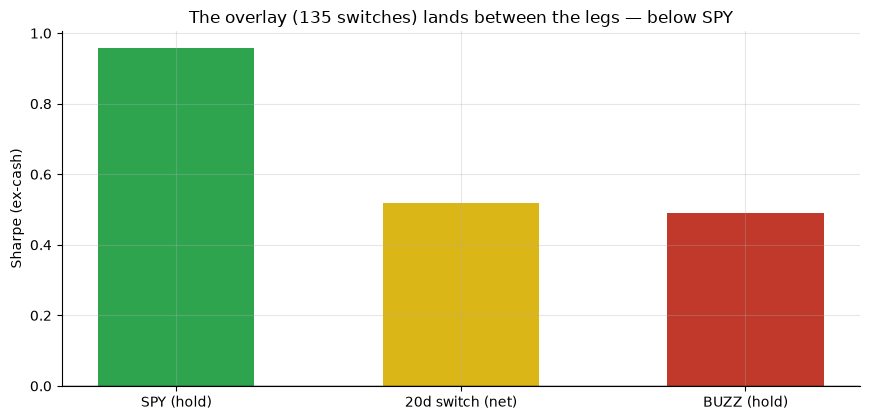

SPY 0.96   overlay 0.52 (135 switches)   BUZZ 0.49


In [5]:
if HAVE_REAL:
    ov = st.sentiment_overlay(REAL, cost_bps=5.0)
    es = st.excess_sharpe(st.daily_returns(REAL))
    sp, bz, ovn = es['sharpe_spy'], es['sharpe_buzz'], ov['sharpe_net']
    nsw = ov['n_switches']
else:
    sp, bz, ovn, nsw = 0.96, 0.49, 0.52, 135
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(['SPY (hold)','20d switch (net)','BUZZ (hold)'], [sp, ovn, bz],
       color=[GREEN, AMBER, RED], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Sharpe (ex-cash)')
ax.set_title(f'The overlay ({nsw} switches) lands between the legs — below SPY')
plt.tight_layout(); plt.show()
print(f'SPY {sp:.2f}   overlay {ovn:.2f} ({nsw} switches)   BUZZ {bz:.2f}')

> 💡 In plain words: the overlay's ~135 switches just burn costs to land between SPY and BUZZ (~0.52 Sharpe), below plain SPY (0.96). There is no configuration of this product, active or passive, that beats the index it races. The cost axis is moot — the gross was already losing.

## 7 · Going further — the synthetic positive control

Is the *engine* a faithful alpha detector, or would it print 'none' on anything? Plant a known alpha and confirm it is recovered (and that a pure dressed-up-beta null is not mistaken for skill).

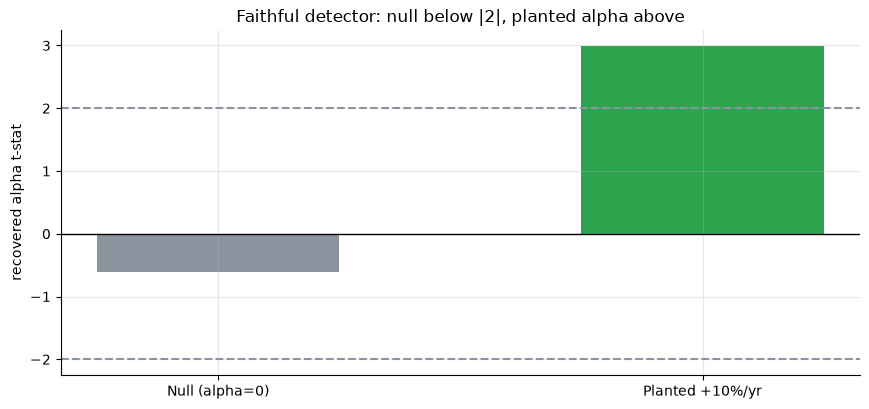

           tape  planted %/yr  recovered %/yr     t
 Null (alpha=0)          0.00           -1.71 -0.61
Planted +10%/yr         10.08            8.37  2.99


In [6]:
rows = []
for ab, lab in [(0.0,'Null (alpha=0)'), (4.0,'Planted +10%/yr')]:
    syn, tr = data.synthetic_pair(n_days=3000, alpha_bps=ab, seed=335)
    a = st.capm_alpha(st.daily_returns(syn))
    rows.append((lab, tr['alpha_bps_ann'], a['alpha_ann_pct'], a['tstat']))
dfm = pd.DataFrame(rows, columns=['tape','planted %/yr','recovered %/yr','t'])
fig, ax = plt.subplots(figsize=(8.8, 4.2))
col = [GREEN if abs(t) >= 2 else GREY for t in dfm['t']]
ax.bar(dfm['tape'], dfm['t'], color=col, width=.5)
ax.axhline(2, ls='--', c=GREY); ax.axhline(-2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('recovered alpha t-stat'); ax.set_title('Faithful detector: null below |2|, planted alpha above')
plt.tight_layout(); plt.show()
print(dfm.round(2).to_string(index=False))

The engine reads **no alpha** on the dressed-up-beta null (*t* = -0.61) and **recovers a planted alpha** at *t* = 2.99 — so it can bank skill when skill is there. (A synthetic control is a *machinery* proof, never market evidence; the `NONE` stamp is earned on the real tape alone.) The real-tape negative result is therefore a statement about **BUZZ**: an AI read of the crowd, shrink-wrapped into a 75-name basket, did not beat the market it listens to.

For the raw signals this fund packages, see [Study 254 — WSB-Mentions](../../254-wsb-mentions/) and [Study 256 — Twitter-Mood](../../256-twitter-mood/) — both also dead on arrival.